In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
train_noisy = pd.read_csv('train.csv', header=None).values.astype(np.float32)
test_noisy = pd.read_csv('test.csv', header=None).values.astype(np.float32)
train_clean = pd.read_csv('etalon_for_train.csv', header=None).values.astype(np.float32)
test_clean = pd.read_csv('etalon_for_test.csv', header=None).values.astype(np.float32)

print(f"Размер train_data: {train_noisy.shape}")
print(f"Размер test_data: {test_noisy.shape}")

print(f"Размер etalon_train: {train_clean.shape}")
print(f"Размер etalon_test: {test_clean.shape}")

Размер train_data: (1000, 5000)
Размер test_data: (500, 5000)
Размер etalon_train: (1000, 5000)
Размер etalon_test: (500, 5000)


Перед обучением модели важно понять природу шума (аддитивный, мультипликативный) и структуру полезного сигнала. Это поможет выбрать подходящую архитектуру и функцию потерь. Также визуализация поможет сравнивать предсказания модели с оригиналом

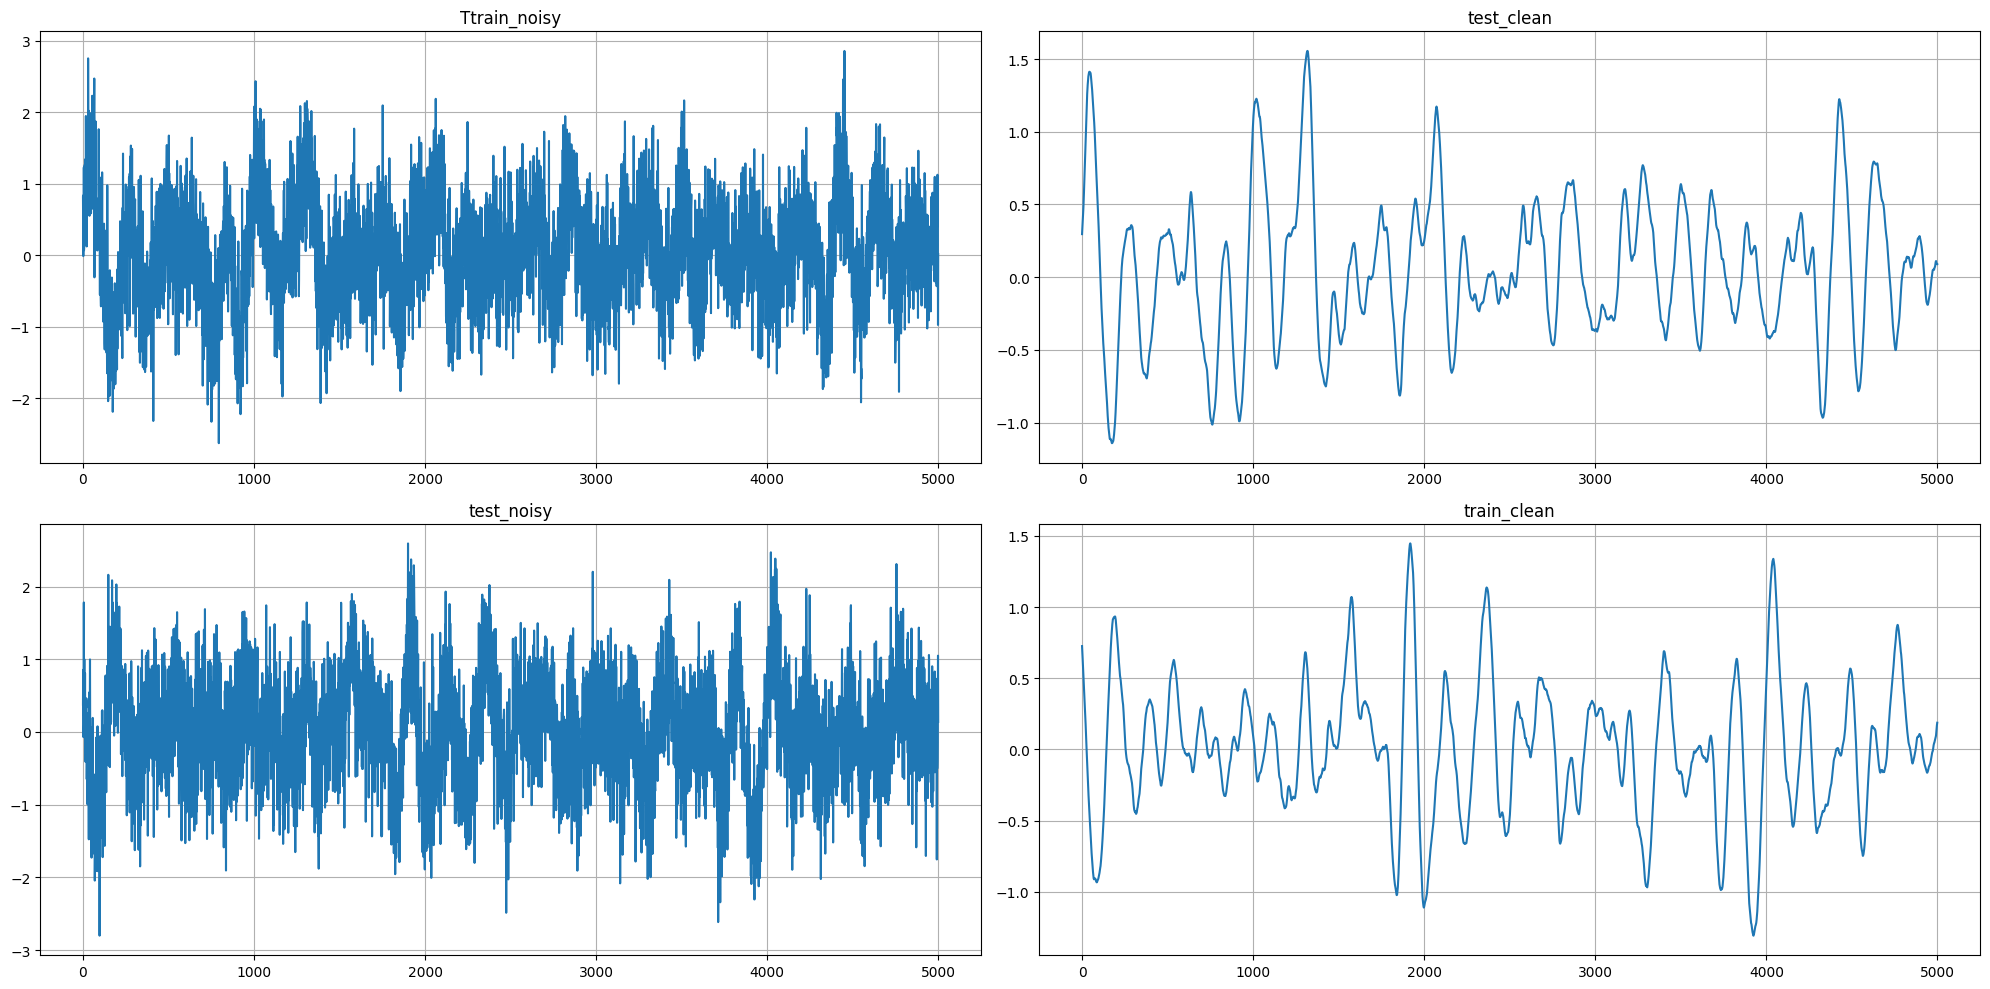

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

axes[0, 0].plot(train_noisy[0])
axes[0, 0].set_title('Ttrain_noisy')
axes[0, 0].grid(True)

axes[0, 1].plot(train_clean[0])
axes[0, 1].set_title('test_clean')
axes[0, 1].grid(True)

axes[1, 0].plot(test_noisy[0])
axes[1, 0].set_title('test_noisy')
axes[1, 0].grid(True)

axes[1, 1].plot(test_clean[0])
axes[1, 1].set_title('train_clean')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

Разделяем на тестовую и тренировочную выборку

In [ ]:
INPUT_LEN = 4000
OUTPUT_LEN = 1000

X = train_noisy[:, :INPUT_LEN]
y = train_clean[:, INPUT_LEN:INPUT_LEN + OUTPUT_LEN]

X_test = test_noisy[:, :INPUT_LEN]
y_test = test_clean[:, INPUT_LEN:INPUT_LEN + OUTPUT_LEN]

print(X.shape, y.shape)
print(X_test.shape, y_test.shape)

(1000, 4000) (1000, 1000)
(500, 4000) (500, 1000)


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

PyTorch работает с тензорами, поэтому массивы numpy преобразуются в torch.Tensor. Для входа добавляется последняя размерность 1, потому что LSTM ожидает формат последовательности [количество объектов, длина последовательности, число признаков]

TensorDataset связывает входы и ответы, а DataLoader подаёт данные батчами. Размер батча 16 выбран как компромисс между стабильностью градиентного шага, скоростью обучения и расходом памяти

Перемешивание обучающей выборки помогает снизить зависимость обучения от порядка примеров, а тестовая выборка не перемешивается для воспроизводимости

In [ ]:
X_tensor = torch.from_numpy(X).unsqueeze(-1).to(device)  # [samples, 4000, 1]
y_tensor = torch.from_numpy(y).to(device)                # [samples, 1000]

X_test_tensor = torch.from_numpy(X_test).unsqueeze(-1).to(device)
y_test_tensor = torch.from_numpy(y_test).to(device)

train_dataset = TensorDataset(X_tensor, y_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

данные являются временными последовательностями, поэтому для задачи хорошо подходит LSTM-модель. LSTM лучше обычной полносвязной сети учитывает порядок отсчетов и способна удерживать информацию на длинных интервалах

Входной размер 1 соответствует одному значению сигнала на каждом шаге.

Скрытый размер 128 позволит модели описать сложную динамику

Два LSTM-слоя позволяют извлекать более сложные временные признаки

После обработки всей входной последовательности берётся последнее скрытое состояние, потому что оно агрегирует информацию о предыдущих 4000 точках

In [ ]:
class LSTMForecast(nn.Module):
    def __init__(self, input_size=1, hidden_size=128, num_layers=2, output_size=1000):
        super(LSTMForecast, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = LSTMForecast().to(device)


В качестве функции потерь используется MSE

MSE сильнее штрафует крупные ошибки, что полезно при восстановлении формы сигнала

Оптимизатор Adam адаптирует скорость обновления параметров и обычно сходится быстрее и стабильнее, чем классический SGD.

In [ ]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Обучаем 100 эпох и сохраняем моель с лучшей RMSE

In [ ]:
import matplotlib.pyplot as plt

epochs = 100
best_rmse = float('inf')
loss_history = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)

    epoch_loss /= len(train_loader.dataset)
    loss_history.append(epoch_loss)

    # Проверка на тестовой выборке, чтобы сохранить лучшую модель
    model.eval()
    y_preds_test = []
    with torch.no_grad():
        for xb_test, _ in test_loader:
            xb_test = xb_test.to(device)
            pred = model(xb_test)
            y_preds_test.append(pred.cpu().numpy())
    y_preds_test_arr = np.vstack(y_preds_test)
    rmse_test = np.sqrt(np.mean((y_preds_test_arr - y_test)**2))

    if rmse_test < best_rmse:
        best_rmse = rmse_test
        torch.save(model.state_dict(), 'best_lstm_model.pth')

    print(f"Эпоха {epoch+1}/{epochs}, Train Loss: {epoch_loss:.6f}, RMSE Test: {rmse_test:.6f}")



Эпоха 1/100, Train Loss: 0.031773, RMSE Test: 0.662623
Эпоха 2/100, Train Loss: 0.030798, RMSE Test: 0.660829
Эпоха 3/100, Train Loss: 0.031134, RMSE Test: 0.665033
Эпоха 4/100, Train Loss: 0.029650, RMSE Test: 0.665544
Эпоха 5/100, Train Loss: 0.028391, RMSE Test: 0.662929
Эпоха 6/100, Train Loss: 0.025859, RMSE Test: 0.663467
Эпоха 7/100, Train Loss: 0.024479, RMSE Test: 0.665931
Эпоха 8/100, Train Loss: 0.023560, RMSE Test: 0.665021
Эпоха 9/100, Train Loss: 0.022589, RMSE Test: 0.668701
Эпоха 10/100, Train Loss: 0.021686, RMSE Test: 0.669257
Эпоха 11/100, Train Loss: 0.021081, RMSE Test: 0.670853
Эпоха 12/100, Train Loss: 0.021091, RMSE Test: 0.668418
Эпоха 13/100, Train Loss: 0.022651, RMSE Test: 0.671000
Эпоха 14/100, Train Loss: 0.028081, RMSE Test: 0.670939
Эпоха 15/100, Train Loss: 0.031276, RMSE Test: 0.665229
Эпоха 16/100, Train Loss: 0.028838, RMSE Test: 0.662929
Эпоха 17/100, Train Loss: 0.023609, RMSE Test: 0.666306
Эпоха 18/100, Train Loss: 0.020914, RMSE Test: 0.663655
Э

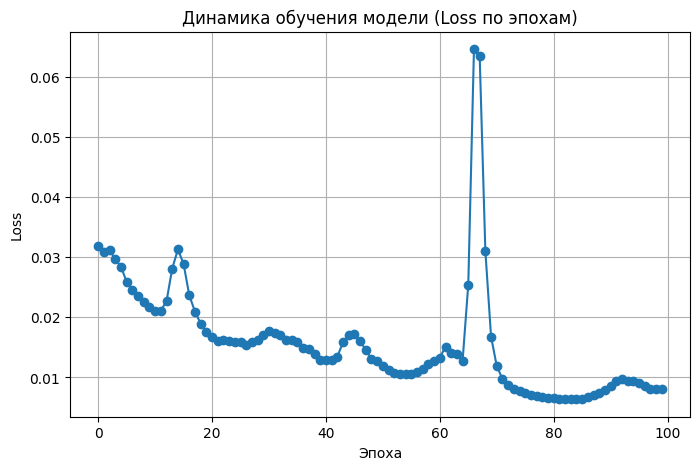

In [ ]:
# График изменения loss
plt.figure(figsize=(8,5))
plt.plot(loss_history, marker='o')
plt.title('Динамика обучения модели (Loss по эпохам)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

График показывает устойчивое снижение функции потерь, что свидетельствует о корректном обучении модели. Наблюдается единичный резкий скачок ошибки, вероятно связанный с нестабильностью оптимизации, однако модель быстро восстанавливается. В конце обучения loss выходит на плато, что говорит о сходимости и отсутствии явного переобучения

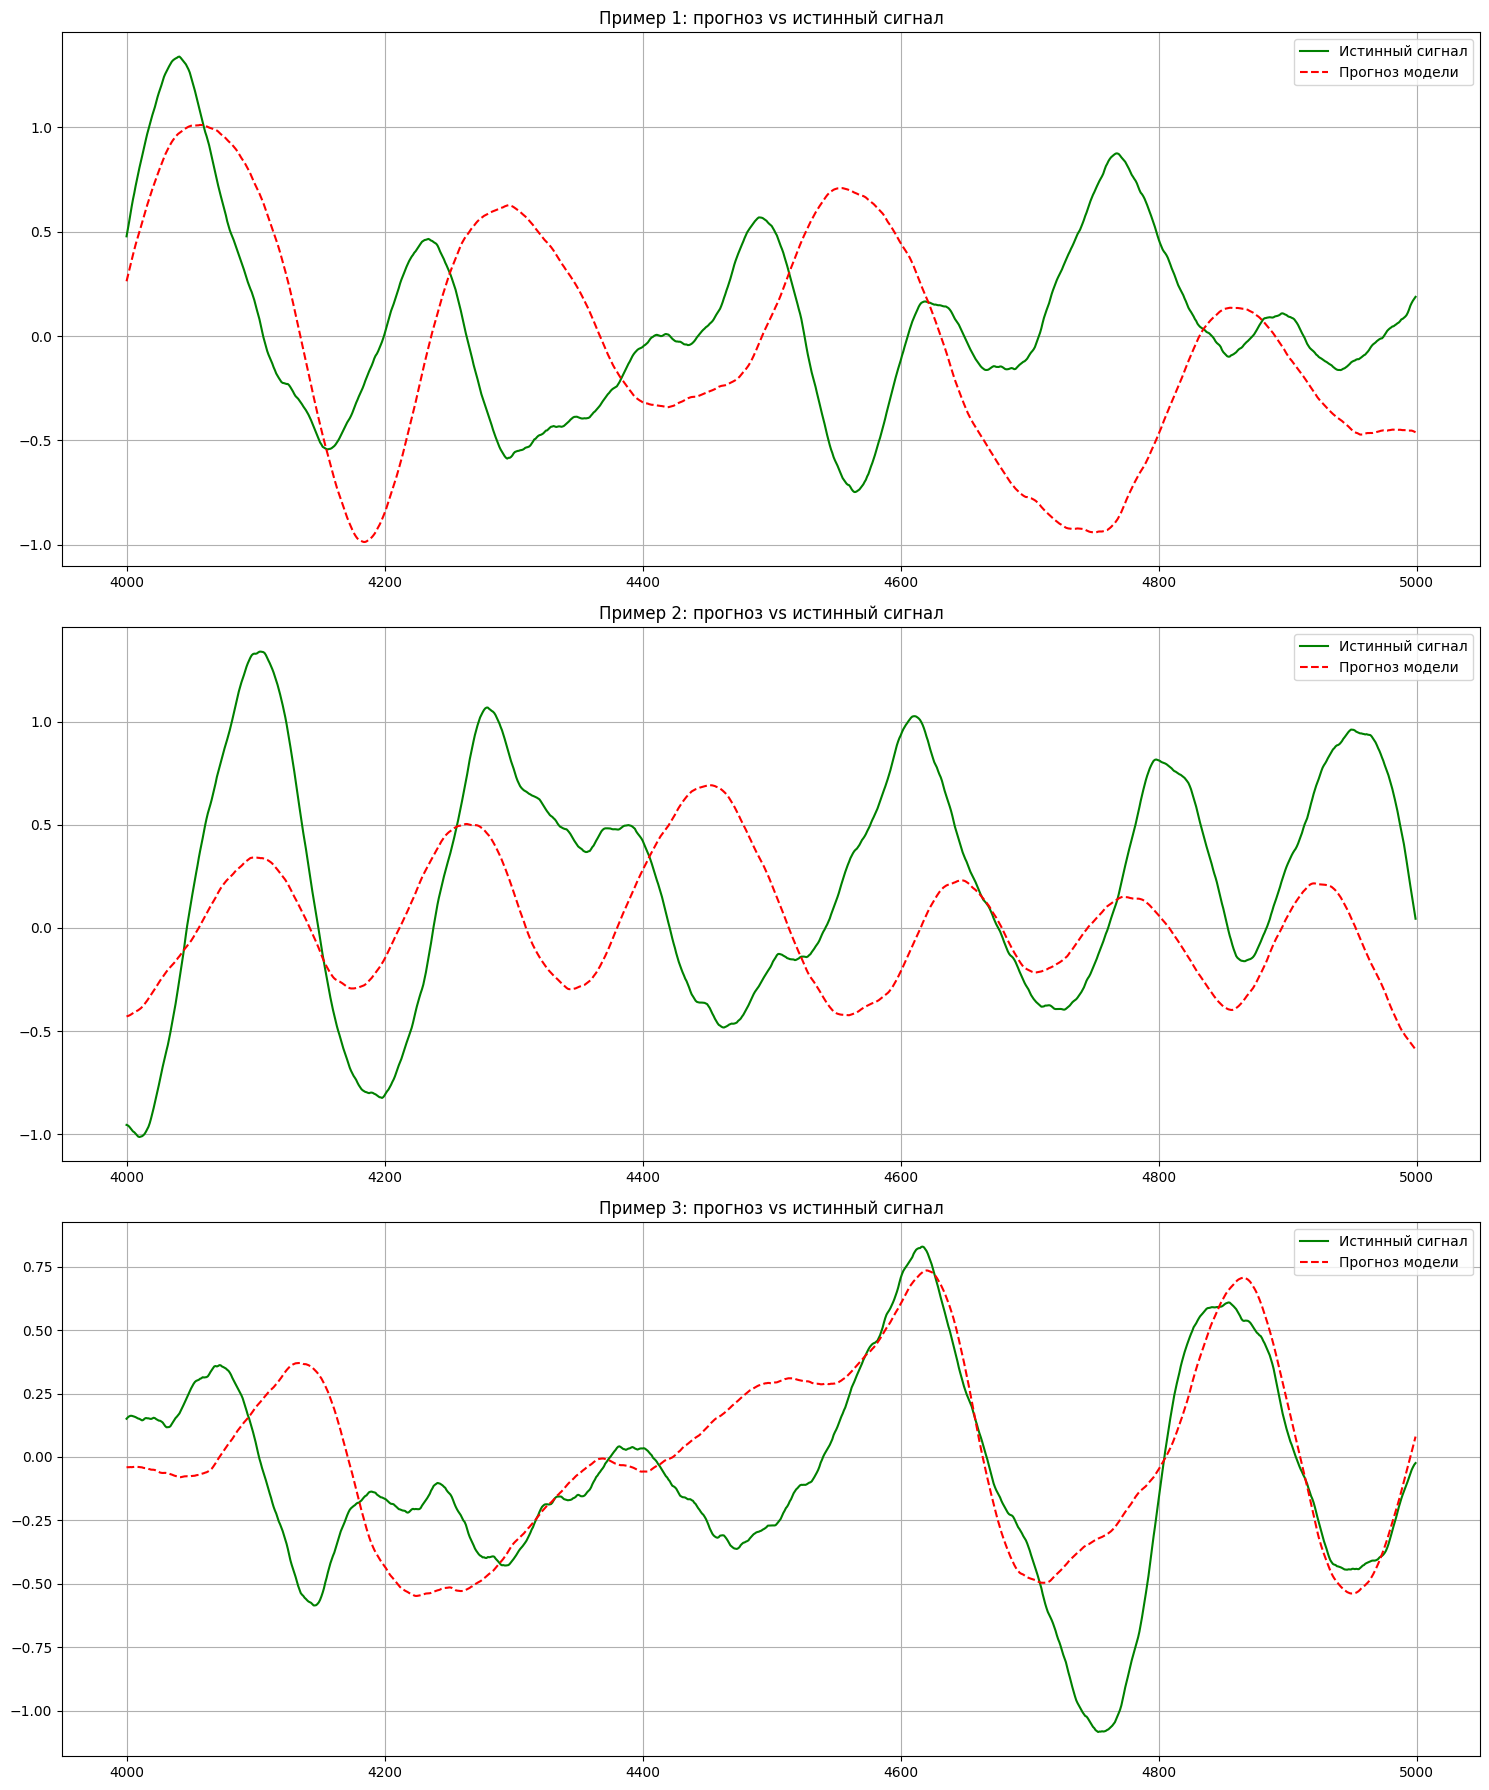

In [ ]:
# Прогноз vs исходный сигнал на 3 примерах
model.load_state_dict(torch.load('best_lstm_model.pth'))
model.eval()

num_examples = 3
fig, axes = plt.subplots(num_examples, 1, figsize=(15, 6*num_examples))

with torch.no_grad():
    for i in range(num_examples):
        xb_example = X_test_tensor[i].unsqueeze(0).to(device)
        pred_example = model(xb_example).cpu().numpy().flatten()
        true_example = y_test[i]

        axes[i].plot(range(INPUT_LEN, INPUT_LEN+OUTPUT_LEN), true_example, label='Истинный сигнал', color='green')
        axes[i].plot(range(INPUT_LEN, INPUT_LEN+OUTPUT_LEN), pred_example, label='Прогноз модели', color='red', linestyle='--')
        axes[i].set_title(f'Пример {i+1}: прогноз vs истинный сигнал')
        axes[i].legend()
        axes[i].grid(True)
plt.tight_layout()
plt.show()

Предсказанные сигналы в целом повторяют форму исходного. Модель хорошо уловила глобальную структуру и тренд

In [ ]:
model.eval()
y_preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        pred = model(xb)
        y_preds.append(pred.cpu().numpy())

y_preds = np.vstack(y_preds)
errors = y_preds - y_test
mean_error = np.mean(errors)
rmse = np.sqrt(np.mean(errors**2))

print(f"Средняя ошибка прогноза: {mean_error:.6f}")
print(f"СКП (RMSE) ошибки прогноза: {rmse:.6f}")

Средняя ошибка прогноза: 0.005385
СКП (RMSE) ошибки прогноза: 0.647034
